
# Data Analysis of Gym Session Dataset

In this notebook, I performed **data analysis** on a dataset containing **973 entries** related to gym sessions. The analysis included the following steps:

1. **Exploratory Data Analysis (EDA)**: I explored features such as workout frequency, experience level, average BPM, and fat percentage to understand their distribution and relationships.
  
2. **Machine Learning Models**: I applied various machine learning models to predict **calories burned** based on selected features. Models used include:
   - Linear Regression
   - Decision Tree
   - Random Forest
   - K-Neighbors Regressor
   - XGBoost
  
3. **Model Evaluation and Tuning**: I evaluated each model's performance using **Mean Squared Error (MSE)** and **R2 score**. Additional steps included:
   - **Feature Importance Analysis** to identify key predictors
   - **Residual Analysis** to assess model accuracy
   - **Cross-Validation** and **Hyperparameter Tuning** to optimize model performance

Overall, this analysis provided insights into the relationships between various features and the calories burned during gym sessions, as well as the predictive power of different models.


In [1]:
# Loading the data
import pandas as pd

file_path = r"C:\Users\upama\Downloads\workout_dataset\gym_members_exercise_tracking.csv"
gym_data = pd.read_csv(file_path)
# Set display 
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a large display width to avoid line breaks

# Display the DataFrame
display(gym_data)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883,HIIT,28.2,2.1,3,2,37.74


This output represents the first few rows of the gym members' exercise tracking dataset, showing various attributes such as age, gender, weight, workout type, and calories burned per session. The dataset contains a total of 973 rows and 15 columns, each capturing different demographic and exercise-related features for analysis.

In [2]:
gym_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    int64  
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

This output provides a summary of the gym members' exercise tracking dataset, displaying the column names, data types, and the count of non-null values for each feature. The dataset has a total of 15 columns and 973 entries, indicating no missing values. It includes demographic information, workout details, and various health metrics.

In [3]:
gym_data.isnull().sum()


Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

This output shows the result of checking for missing values in each column of the dataset. Each column has a value of 0, indicating that there are no missing values in the dataset. This ensures data completeness and reliability for further analysis.

In [4]:
# Check and remove duplicate rows
duplicate_rows = gym_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Remove duplicates if any
gym_data = gym_data.drop_duplicates()


Number of duplicate rows: 0


In [5]:
import numpy as np
# Specify only the numeric columns to calculate the IQR for outlier removal
numeric_columns = gym_data.select_dtypes(include=[np.number]).columns

# Calculate Q1 and Q3 for the numeric columns
Q1 = gym_data[numeric_columns].quantile(0.25)
Q3 = gym_data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Filter out the outliers based on the IQR method
gym_data = gym_data[~((gym_data[numeric_columns] < (Q1 - 1.5 * IQR)) | (gym_data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]


print("This code performs outlier removal based on the Interquartile Range (IQR) method. First, it identifies numeric columns, then calculates the first (Q1) and third quartiles (Q3) for each column to determine the IQR. Rows with values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are considered outliers and removed from the dataset. This ensures that extreme values do not skew further analysis.")


This code performs outlier removal based on the Interquartile Range (IQR) method. First, it identifies numeric columns, then calculates the first (Q1) and third quartiles (Q3) for each column to determine the IQR. Rows with values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are considered outliers and removed from the dataset. This ensures that extreme values do not skew further analysis.


In [6]:
gym_data.describe()


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000,932.000000
mean,38.805794,72.118240,1.723337,179.920601,143.452790,62.182403,1.253798,898.076180,25.136373,2.612017,3.314378,1.803648,24.273938
std,12.120140,19.581836,0.128488,11.513226,14.301605,7.361393,0.340060,262.988423,6.225982,0.600470,0.913491,0.739457,5.837905
min,18.000000,40.000000,1.500000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,57.775000,1.620000,170.000000,131.000000,56.000000,1.040000,719.750000,21.300000,2.100000,3.000000,1.000000,19.902500
50%,40.000000,68.700000,1.715000,180.000000,143.000000,62.000000,1.260000,887.500000,26.400000,2.600000,3.000000,2.000000,23.880000
75%,50.000000,83.925000,1.800000,190.000000,156.000000,68.000000,1.450000,1071.250000,29.400000,3.100000,4.000000,2.000000,27.945000
max,59.000000,127.500000,2.000000,199.000000,169.000000,74.000000,1.990000,1598.000000,35.000000,3.700000,5.000000,3.000000,41.030000


The table above displays summary statistics for the numeric features in the dataset. Key statistics include:
- Mean: The average value of each feature.
- Standard Deviation (std): Measures the variability or spread of values around the mean.
- Minimum and Maximum: The lowest and highest values in each feature.
- 25%, 50%, and 75% Percentiles: Also known as the quartiles, these values help in understanding the distribution of each feature. The 50% (median) is particularly useful as it represents the middle value.

These statistics provide a general overview of the dataset, helping identify trends such as the average workout frequency, calorie burn, and distribution of height and weight among gym members.

In [7]:

print(gym_data['Gender'].value_counts())


Gender
Male      471
Female    461
Name: count, dtype: int64


In [8]:

# Display the count distribution for Gender and Experience Level
gender_distribution = gym_data['Gender'].value_counts(normalize=True) * 100
experience_distribution = gym_data['Experience_Level'].value_counts(normalize=True) * 100

print("Gender Distribution (%):")
print(gender_distribution)
print("\nExperience Level Distribution (%):")
print(experience_distribution)


Gender Distribution (%):
Gender
Male      50.536481
Female    49.463519
Name: proportion, dtype: float64

Experience Level Distribution (%):
Experience_Level
2    41.523605
1    39.055794
3    19.420601
Name: proportion, dtype: float64


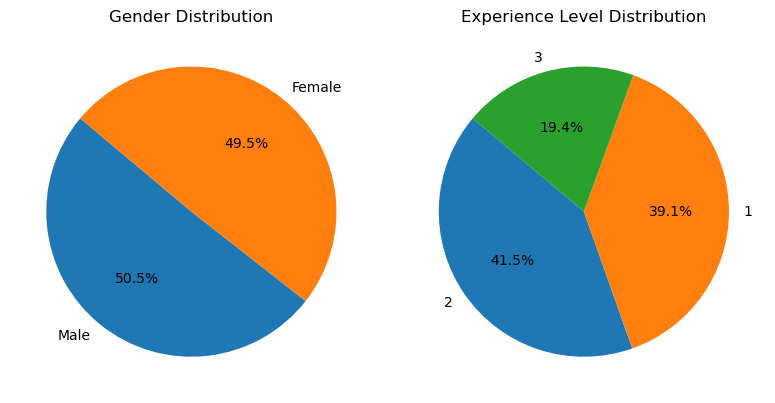

In [9]:

import matplotlib.pyplot as plt

# Pie chart for Gender Distribution
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.pie(gender_distribution, labels=gender_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender Distribution')

# Pie chart for Experience Level Distribution
plt.subplot(1, 2, 2)
plt.pie(experience_distribution, labels=experience_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Experience Level Distribution')

plt.tight_layout()
plt.show()


# Explanation of Pie Charts
The charts above illustrate the distribution of gym members by gender and experience level:
1. Gender Distribution: The gender split among gym members is nearly even, with 50.5% male and 49.5% female. This balanced distribution indicates that the gym attracts a fairly equal number of male and female members, allowing for diverse class offerings and facilities.
2. Experience Level Distribution: The experience levels of members are divided as follows:
  - 39.1% are beginners (level 1),
  - 41.5% are intermediate (level 2), and
  - 19.4% are advanced (level 3).


This distribution suggests that most members are in the early to intermediate stages of their fitness journey, highlighting an opportunity for the gym to focus on beginner-friendly programs and gradual progression training.

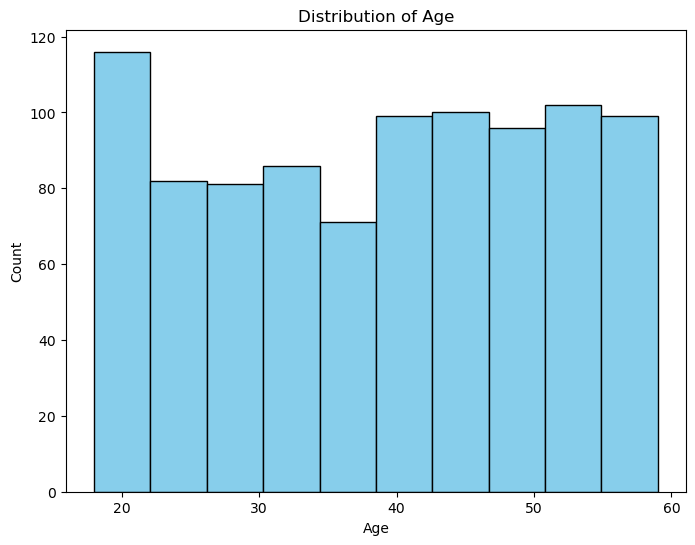

In [10]:

# Plot histogram for Age distribution
plt.figure(figsize=(8, 6))
plt.hist(gym_data['Age'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.show()


# Explanation of Age Distribution Histogram
The histogram above shows the distribution of gym members' ages. Key observations include:
1. The 20-29 age group has the highest number of members, indicating that younger adults are highly engaged in gym activities.
2. There is a fairly consistent distribution across age groups from 30 to 59, suggesting that the gym attracts a diverse range of ages.

This age distribution highlights that the gym has a broad demographic appeal, catering to both younger and older adults, allowing for a range of classes and services that appeal to different life stages.


Descriptive Statistics for Key Variables:
              BMI  Session_Duration (hours)  Workout_Frequency (days/week)
count  932.000000                932.000000                     932.000000
mean    24.273938                  1.253798                       3.314378
std      5.837905                  0.340060                       0.913491
min     12.320000                  0.500000                       2.000000
25%     19.902500                  1.040000                       3.000000
50%     23.880000                  1.260000                       3.000000
75%     27.945000                  1.450000                       4.000000
max     41.030000                  1.990000                       5.000000


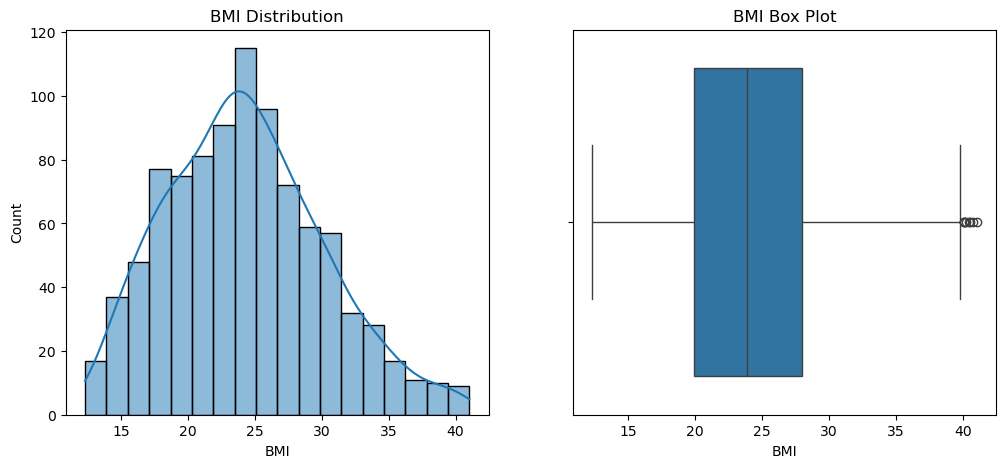

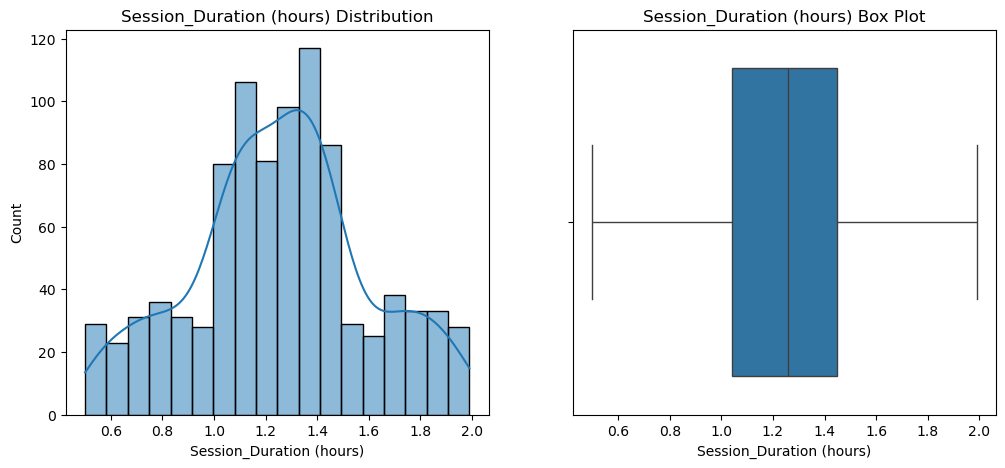

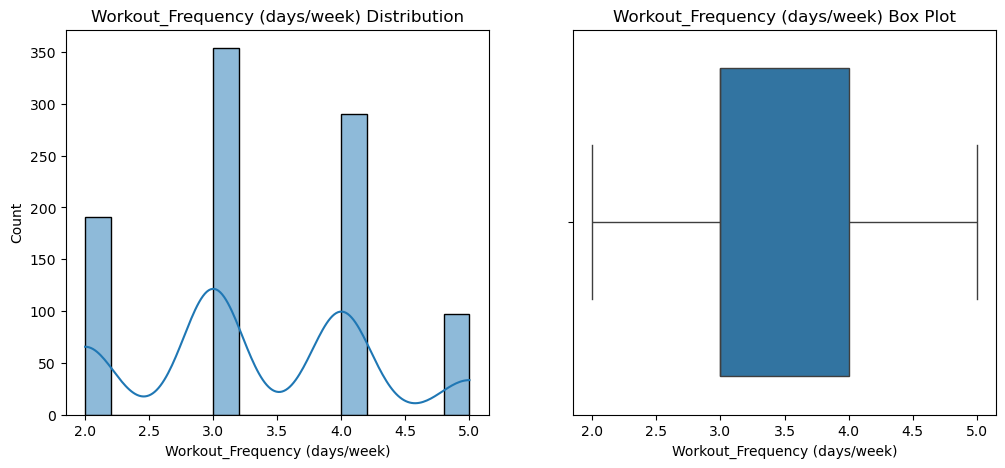

In [11]:

import seaborn as sns

# Describe key numerical variables
print("Descriptive Statistics for Key Variables:")
print(gym_data[['BMI', 'Session_Duration (hours)', 'Workout_Frequency (days/week)']].describe())

# Visualize distributions with histograms and box plots
variables = ['BMI', 'Session_Duration (hours)', 'Workout_Frequency (days/week)']

for variable in variables:
    plt.figure(figsize=(12, 5))

    # Histogram for distribution
    plt.subplot(1, 2, 1)
    sns.histplot(gym_data[variable], kde=True)
    plt.title(f'{variable} Distribution')
    
    # Box plot for outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=gym_data[variable])
    plt.title(f'{variable} Box Plot')
    
    plt.show()


# Explanation for Distribution and Box Plots of Key Variables
The visualizations above show the distributions and box plots for three key variables: 
BMI, 
Session Duration,
and Workout Frequency.


The histogram shows that most gym members have a BMI ranging between 20 to 30, with a peak around 25. The box plot reveals a few outliers on the higher side, indicating members with higher BMIs.

Session Duration (hours):

Session Duration appears to follow a fairly normal distribution centered around 1.2 hours. The box plot confirms this by showing a consistent interquartile range, with no extreme outliers.

Workout Frequency (days/week):

The histogram for Workout Frequency shows peaks at specific intervals, suggesting that members have a preference for working out a set number of days each week. The box plot also indicates that the data is spread across the entire range from 2 to 5 days, without any significant outliers.


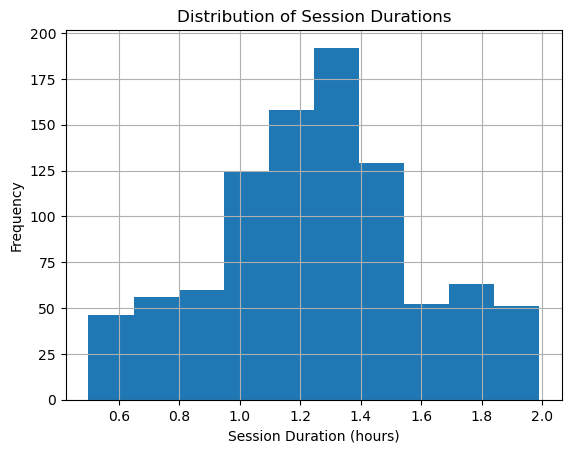

In [12]:


# Plot histogram of the 'Session_Duration (hours)' column
gym_data['Session_Duration (hours)'].hist()
plt.xlabel('Session Duration (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Session Durations')
plt.show()



# Explanation of Session Duration Distribution

The histogram above illustrates the distribution of session durations among gym members. Most sessions fall within the range of 1 to 1.5 hours, with a noticeable peak around 1.3 hours. This suggests that the majority of gym members prefer workouts lasting just over an hour. There is a smaller number of sessions at the extremes—both shorter (0.5 hours) and longer (2 hours)—indicating that very short and very long workout sessions are less common.



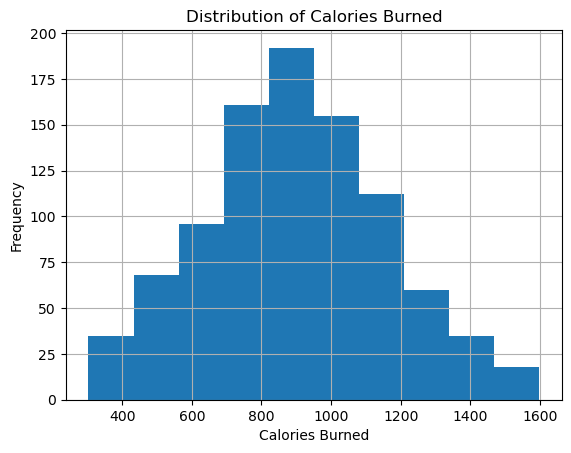

In [13]:

gym_data['Calories_Burned'].hist()
plt.xlabel('Calories Burned')
plt.ylabel('Frequency')
plt.title('Distribution of Calories Burned')
plt.show()



# Explanation of Calories Burned Distribution
The histogram above displays the distribution of calories burned during gym sessions. Most sessions result in calorie burns between 700 and 1100 calories, with a peak around 900 calories. This pattern suggests that a majority of workouts fall within a moderate calorie expenditure range, while fewer sessions lead to either very low or very high calorie burns. This information can help the gym design programs targeting members' fitness goals based on typical calorie expenditures.

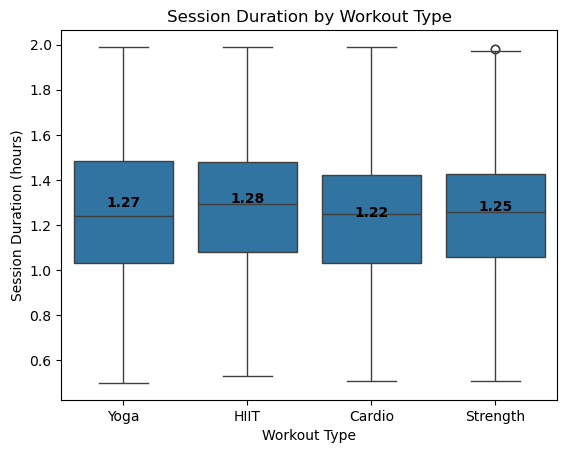

In [14]:

# Create the box plot
sns.boxplot(x='Workout_Type', y='Session_Duration (hours)', data=gym_data)
plt.xlabel('Workout Type')
plt.ylabel('Session Duration (hours)')
plt.title('Session Duration by Workout Type')

# Calculate the mean Session Duration for each Workout Type and annotate it
mean_values = gym_data.groupby('Workout_Type')['Session_Duration (hours)'].mean()
for workout_type, mean_value in mean_values.items():
    plt.text(x=workout_type, y=mean_value, s=f'{mean_value:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold')

plt.show()

# Explanation of Session Duration by Workout Type
The box plot above illustrates the distribution of session durations across different workout types. I observe that the average session durations are fairly consistent across workout types, with HIIT sessions being slightly longer (1.28 hours on average) compared to Cardio (1.22 hours). Yoga sessions average around 1.27 hours, and Strength training sessions are close behind at 1.25 hours. This uniformity suggests that members generally spend a similar amount of time across all workout types, but there may be minor variations based on the intensity and nature of each workout.



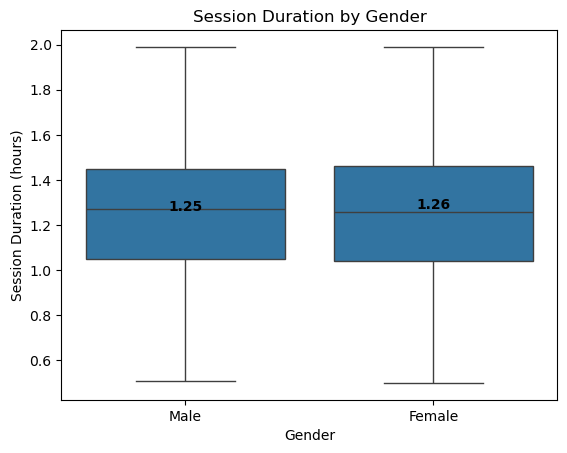

In [15]:


# Create the box plot
sns.boxplot(x='Gender', y='Session_Duration (hours)', data=gym_data)
plt.xlabel('Gender')
plt.ylabel('Session Duration (hours)')
plt.title('Session Duration by Gender')

# Calculate the mean Session Duration for each Gender and annotate it
mean_values = gym_data.groupby('Gender')['Session_Duration (hours)'].mean()
for gender, mean_value in mean_values.items():
    plt.text(x=gender, y=mean_value, s=f'{mean_value:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


# Explanation of Session Duration by Gender
The box plot above shows the distribution of session durations between male and female gym members. Both genders display a similar range in session duration, with a slight difference in the average time spent per session: males average 1.25 hours, while females average 1.26 hours. This minimal variation suggests that gym members, regardless of gender, tend to spend roughly the same amount of time per session, indicating consistent workout commitment across genders.


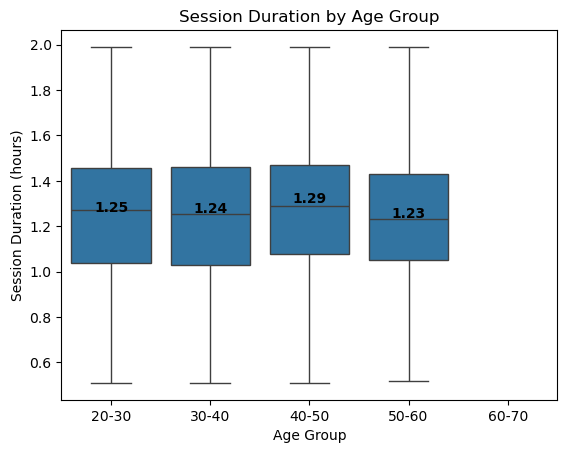

In [16]:


# Create age groups
gym_data['Age_Group'] = pd.cut(gym_data['Age'], bins=[20, 30, 40, 50, 60, 70], labels=['20-30', '30-40', '40-50', '50-60', '60-70'])

# Drop rows with missing values in 'Age_Group' or 'Session_Duration (hours)'
filtered_data = gym_data.dropna(subset=['Age_Group', 'Session_Duration (hours)'])

# Plot box plot for Session Duration by Age Group
sns.boxplot(x='Age_Group', y='Session_Duration (hours)', data=filtered_data)
plt.xlabel('Age Group')
plt.ylabel('Session Duration (hours)')
plt.title('Session Duration by Age Group')

# Calculate the mean Session Duration for each Age Group and annotate it
mean_values = filtered_data.groupby('Age_Group', observed=True)['Session_Duration (hours)'].mean()
for age_group, mean_value in mean_values.items():
    plt.text(x=age_group, y=mean_value, s=f'{mean_value:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


# Explanation of Session Duration by Age Group
The box plot above illustrates the average session duration across different age groups. The 40-50 age group spends the longest average time per session (1.29 hours), while the 60-70 age group has the shortest average session duration (1.23 hours). Overall, there is minimal variation between age groups, with all groups maintaining a similar time commitment per session. This suggests that gym members, regardless of age, tend to engage in workouts of comparable duration.

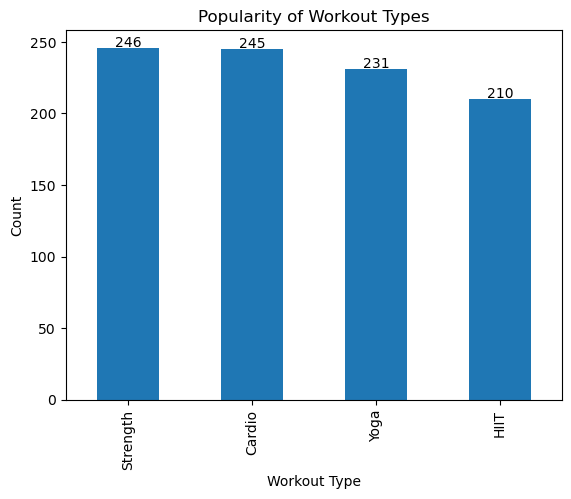

In [17]:


# Plot the bar chart
workout_counts = gym_data['Workout_Type'].value_counts()
workout_counts.plot(kind='bar')
plt.xlabel('Workout Type')
plt.ylabel('Count')
plt.title('Popularity of Workout Types')

# Add exact count labels on top of each bar
for index, value in enumerate(workout_counts):
    plt.text(index, value + 1, str(value), ha='center')  # Adjust `value + 1` as needed for spacing

plt.show()


# Explanation of Popularity of Workout Types
The bar chart illustrates the distribution of workout types among gym members. Strength training is the most popular workout choice with 246 members, closely followed by cardio (245 members) and yoga (231 members). HIIT is the least popular, with 210 members participating. These insights suggest that gym members have a balanced interest across workout types, though there is a slight preference for strength training, which may indicate a focus on muscle building.

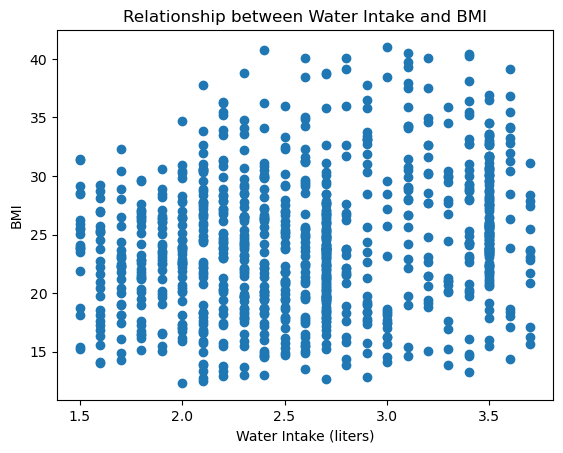

In [18]:
plt.scatter(gym_data['Water_Intake (liters)'], gym_data['BMI'])
plt.xlabel('Water Intake (liters)')
plt.ylabel('BMI')
plt.title('Relationship between Water Intake and BMI')
plt.show() 

# Explanation of Relationship between Water Intake and BMI
The scatter plot shows the relationship between water intake (in liters) and BMI among gym members. There is no clear linear trend, indicating that water intake does not have a straightforward correlation with BMI. However, it is observed that members with a BMI above 30 tend to have varying levels of water intake, suggesting diverse hydration habits irrespective of BMI classification. This distribution emphasizes the need for personalized hydration recommendations based on individual fitness and health goals rather than BMI alone.

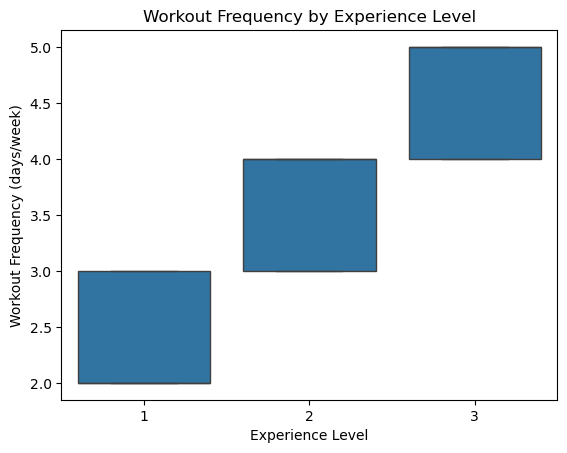

In [19]:

sns.boxplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=gym_data)
plt.xlabel('Experience Level')
plt.ylabel('Workout Frequency (days/week)')
plt.title('Workout Frequency by Experience Level')
plt.show()

# Explanation of Workout Frequency by Experience Level
This box plot illustrates the relationship between workout frequency (days per week) and experience level among gym members. As experience level increases, there is a noticeable increase in workout frequency. Beginner members (Experience Level 1) tend to work out around 3 days per week on average, while intermediate members (Experience Level 2) increase this to around 4 days per week. Advanced members (Experience Level 3) have the highest frequency, averaging close to 5 days per week. This trend suggests a positive correlation between experience and commitment to frequent workouts, indicating that more experienced gym members are likely more consistent in their exercise routines.


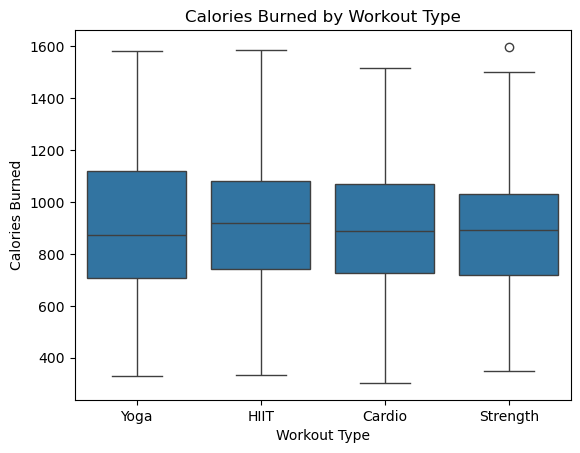

In [20]:
sns.boxplot(x='Workout_Type', y='Calories_Burned', data=gym_data)
plt.xlabel('Workout Type')
plt.ylabel('Calories Burned')
plt.title('Calories Burned by Workout Type')
plt.show()

# Explanation of Calories Burned by Workout Type
This box plot illustrates the distribution of calories burned across different workout types among gym members. The median calories burned are fairly similar across Yoga, HIIT, Cardio, and Strength, suggesting consistent energy expenditure regardless of workout type. However, Yoga and HIIT display a wider range, indicating variability in intensity or session length within these categories. Notably, Strength training has an outlier on the higher end, suggesting a few high-calorie sessions, possibly due to extended duration or increased intensity. This plot helps identify the potential calorie burn associated with each workout type, which could be valuable for members targeting specific calorie goals.


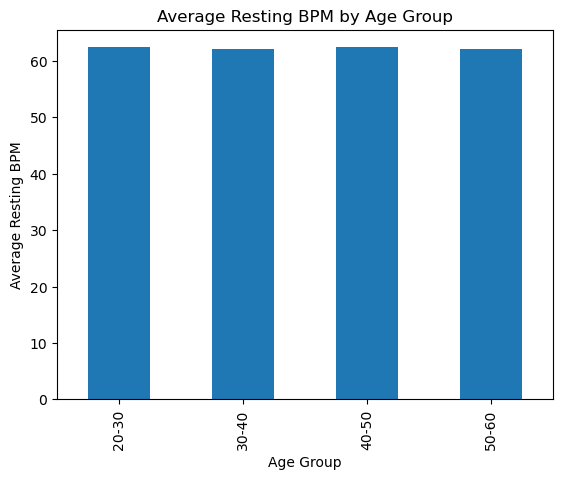

In [21]:
gym_data.groupby('Age_Group', observed=True)['Resting_BPM'].mean().plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Average Resting BPM')
plt.title('Average Resting BPM by Age Group')
plt.show()

# Explanation of Average Resting BPM by Age Group
This bar chart shows the average resting heart rate (BPM) across different age groups of gym members. The average resting BPM is fairly consistent across all age groups, indicating similar baseline fitness or resting states among members. Despite slight variations, the lack of a significant trend suggests that resting BPM might be more influenced by individual fitness levels or health factors than by age alone. This insight is useful for understanding the general cardiovascular health of the gym’s client.

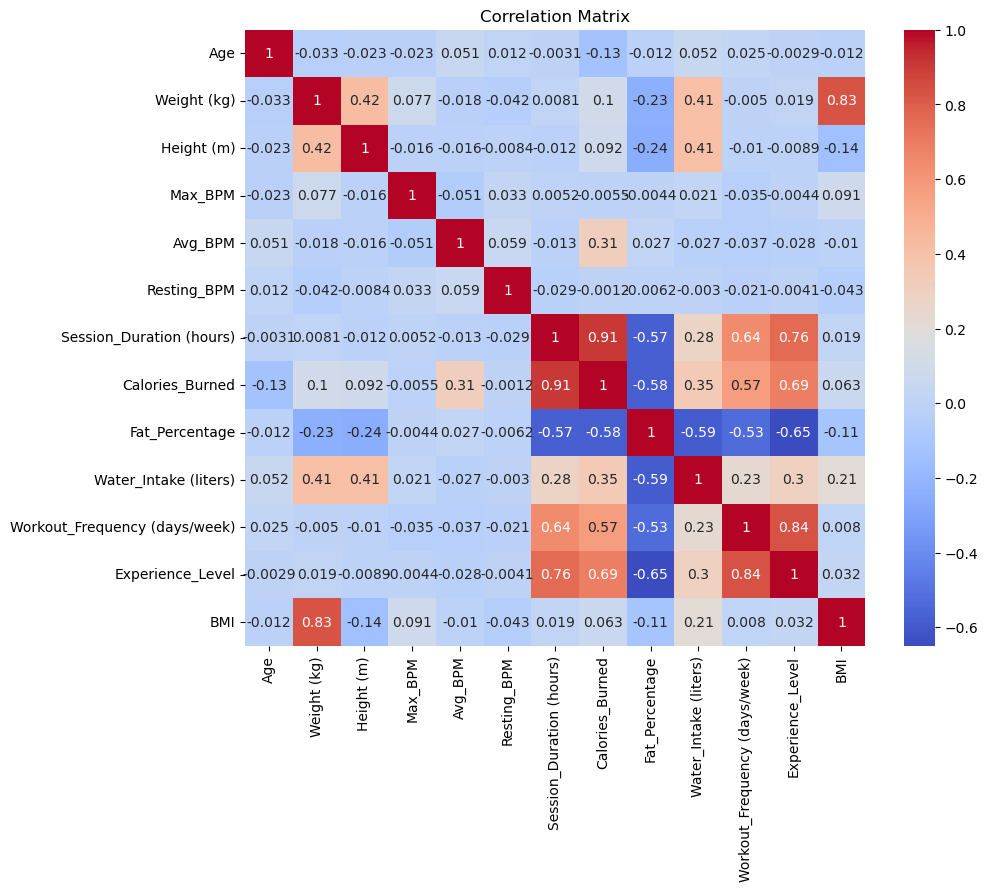

In [22]:


# Select only the numeric columns for the correlation matrix
numeric_data = gym_data.select_dtypes(include='number')

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Explanation of Correlation Matrix
The correlation matrix visualizes the relationships between various numerical features in the gym dataset. Darker colors indicate stronger correlations, either positive or negative. For instance, we observe a strong positive correlation between Weight and BMI, which is expected as BMI is calculated using weight and height. Calories Burned shows a high positive correlation with Session Duration, suggesting that longer workouts tend to burn more calories. Conversely, Fat Percentage has a notable negative correlation with factors like Water Intake and Workout Frequency, possibly indicating that more frequent and better-hydrated gym members have lower fat percentages. These insights help identify key patterns in gym behavior and fitness outcomes.



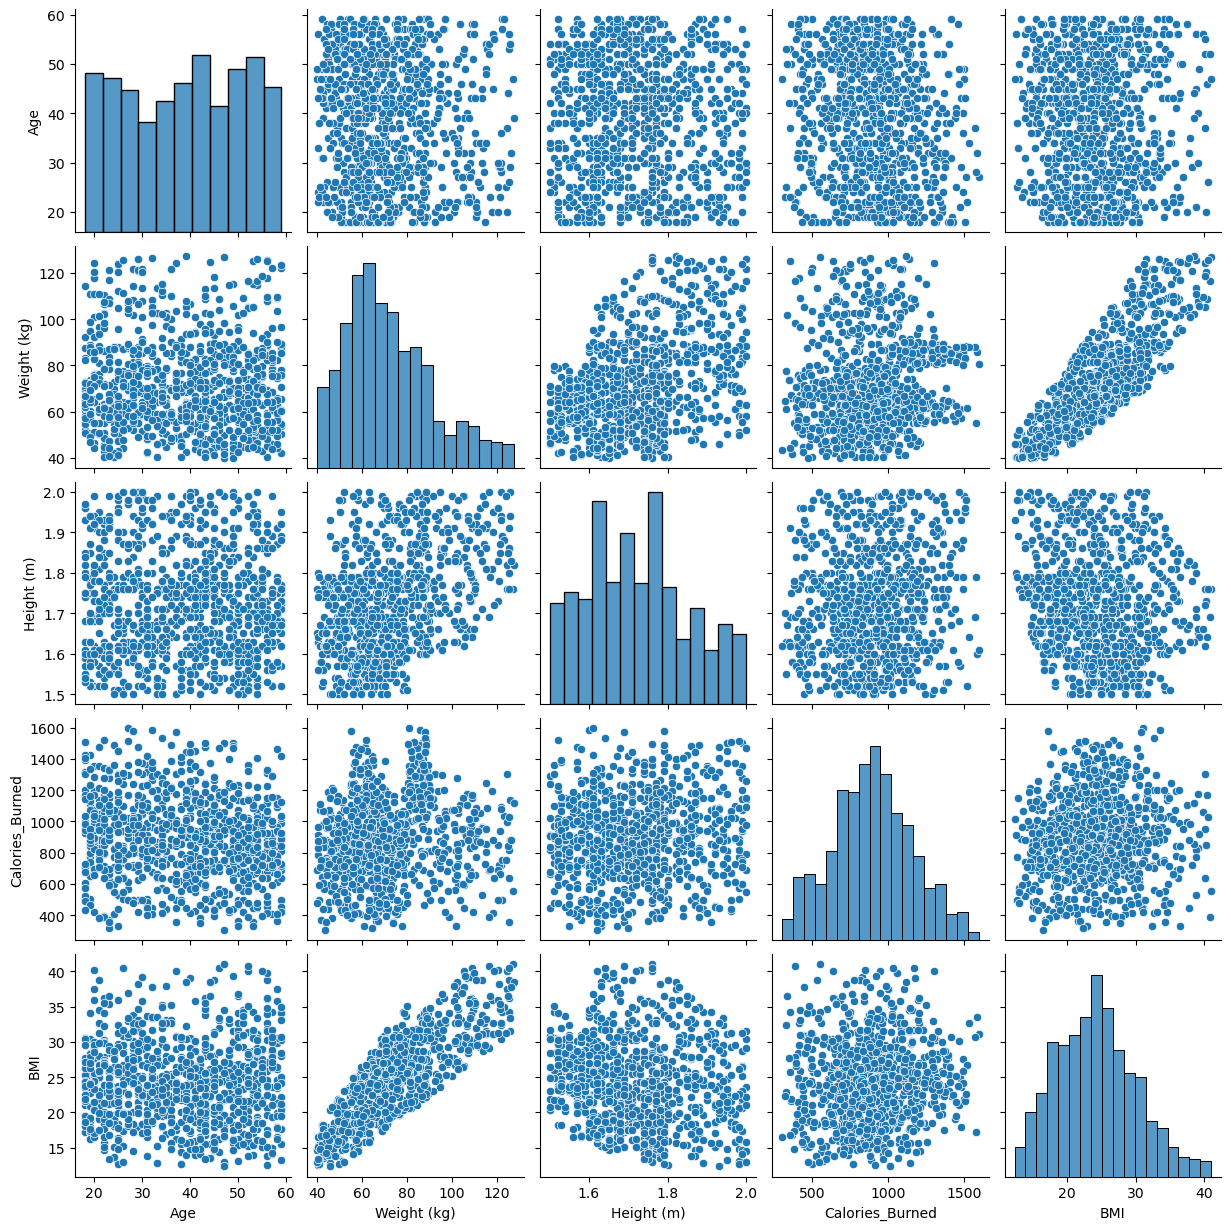

In [23]:
sns.pairplot(gym_data[['Age', 'Weight (kg)', 'Height (m)', 'Calories_Burned', 'BMI']])
plt.show()

The pair plot here provides a visual overview of the relationships between several numerical features in the gym dataset, including Age, Weight, Height, Calories Burned, and BMI. Each scatterplot in the grid shows the relationship between two variables, helping to identify trends and correlations at a glance. For example, a strong positive correlation is noticeable between Weight and BMI, as expected. Additionally, we can see the distribution of each variable along the diagonal, allowing for quick insights into the spread and concentration of values across the dataset. This visual is particularly useful in exploratory data analysis for detecting patterns and possible linear relationships.

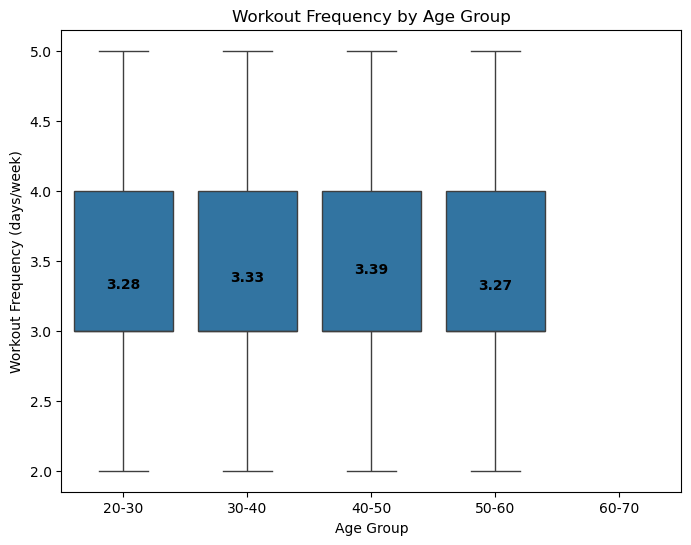

In [24]:

# Remove rows with missing values in 'Age_Group' or 'Workout_Frequency (days/week)'
filtered_data = gym_data.dropna(subset=['Age_Group', 'Workout_Frequency (days/week)'])

# Calculate the mean workout frequency for each age group
mean_workout_frequency = filtered_data.groupby('Age_Group', observed=True)['Workout_Frequency (days/week)'].mean()

# Plot the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Age_Group', y='Workout_Frequency (days/week)', data=filtered_data)
plt.title('Workout Frequency by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Workout Frequency (days/week)')

# Add the mean values as text labels on the plot
for index, (age_group, mean_value) in enumerate(mean_workout_frequency.items()):
    plt.text(index, mean_value, f'{mean_value:.2f}', ha='center', va='bottom', fontweight='bold', color='black')

plt.show()

This box plot visualizes the average workout frequency per week across different age groups in the gym dataset. Each age group is represented along the x-axis, while the y-axis shows the workout frequency (in days per week). The mean values are annotated on each bar, indicating slight variations between groups. The plot suggests that the age groups 40-50 and 30-40 have the highest average workout frequency (3.39 and 3.33 days per week, respectively), while the age group 60-70 has the lowest (3.27 days per week). This insight can help the gym target specific age groups for engagement or improvement programs to increase consistency in workout attendance.



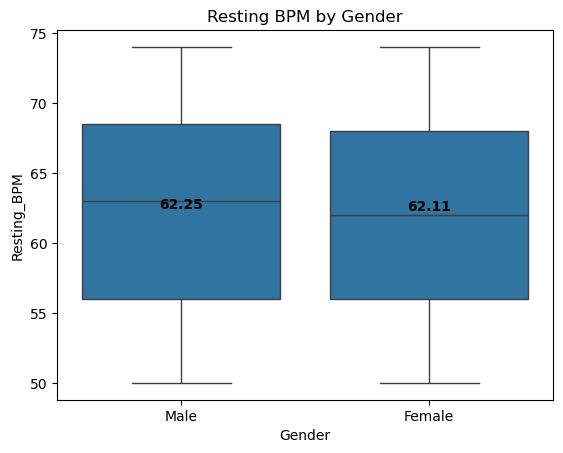

In [25]:

# Create the box plot
sns.boxplot(x='Gender', y='Resting_BPM', data=gym_data)
plt.title('Resting BPM by Gender')

# Calculate the mean Resting_BPM for each gender and annotate it
mean_values = gym_data.groupby('Gender')['Resting_BPM'].mean()
for gender, mean_value in mean_values.items():
    plt.text(x=gender, y=mean_value, s=f'{mean_value:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


The box plot visualizes the distribution of resting heart rates (BPM) for male and female gym members. 
On average, males have a slightly higher resting BPM (62.25) compared to females (62.11). 
      The box plot shows that the median resting BPM is similar for both genders, with a range spanning from 
      approximately 50 to 75 BPM. This plot helps in understanding whether there is any significant difference 
      in resting heart rates across genders.


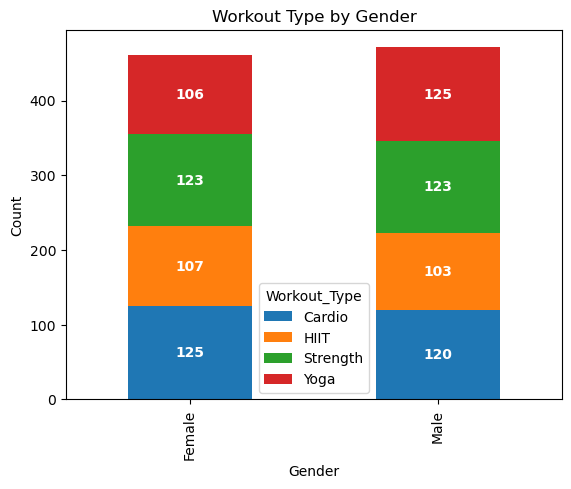

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the crosstab and plot it
crosstab_data = pd.crosstab(gym_data['Gender'], gym_data['Workout_Type'])
crosstab_data.plot(kind='bar', stacked=True)
plt.title('Workout Type by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Add exact count labels on each segment
for gender_index, gender in enumerate(crosstab_data.index):
    cumulative_height = 0
    for workout_type in crosstab_data.columns:
        count = crosstab_data.loc[gender, workout_type]
        if count > 0:
            plt.text(gender_index, cumulative_height + count / 2, str(count), 
                     ha='center', va='center', color='white', fontweight='bold')
            cumulative_height += count

plt.show()

The stacked bar chart displays the distribution of workout types among male and female gym members. 
      Each color represents a different workout type (Cardio, HIIT, Strength, and Yoga). From the plot, we can observe that: 
      - Cardio and Yoga are slightly more popular among females, with 125 participants each in these categories.
      - Males tend to favor Strength and HIIT workouts slightly more.
      - Yoga shows the highest count among males, with 125 participants, while the counts are quite balanced across all categories for both genders.
      This visualization helps in understanding gender preferences for various workout types at the gym, which can aid in designing targeted fitness programs.


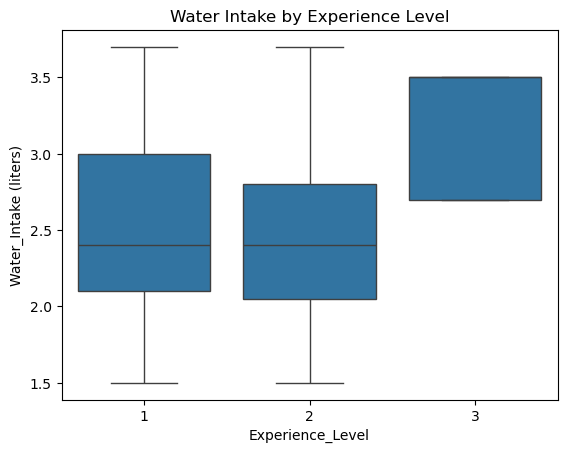

In [27]:
sns.boxplot(x='Experience_Level', y='Water_Intake (liters)', data=gym_data)
plt.title('Water Intake by Experience Level')
plt.show()

The box plot illustrates the distribution of water intake (in liters) across different experience levels of gym members.
      Key observations from the plot include:
      - Members with higher experience levels (Level 3) have a higher median water intake compared to those with lower experience levels (Levels 1 and 2).
      - There is more variation in water intake among beginners (Level 1), with a broader interquartile range.
      - Experienced members (Level 3) show a more consistent and higher water intake, which could indicate better hydration habits developed over time.
      This analysis highlights that as experience level increases, members tend to consume more water, possibly due to greater awareness of hydration's role in fitness.


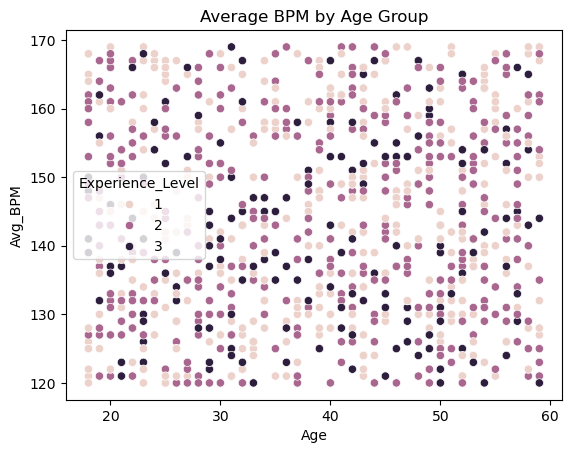

In [28]:
sns.scatterplot(x='Age', y='Avg_BPM', data=gym_data, hue='Experience_Level')
plt.title('Average BPM by Age Group')
plt.show()

The scatter plot represents the relationship between Age and Average BPM (Beats Per Minute) of gym members, with color hues indicating different Experience Levels.
    
    Key observations from the plot include:
    
      - There is a noticeable spread in average BPM across all age groups, with no strong trend showing a correlation between age and BPM.
      - Experience Level is shown as a hue, with darker shades representing higher experience levels. This color differentiation helps to observe any potential differences in BPM based on experience.
      - Regardless of age, higher experience levels (darker shades) do not seem to consistently correspond with higher or lower average BPM values.
     

Overall, this plot indicates that age and experience level may not have a strong influence on average BPM, as the data points are widely distributed across all ages.


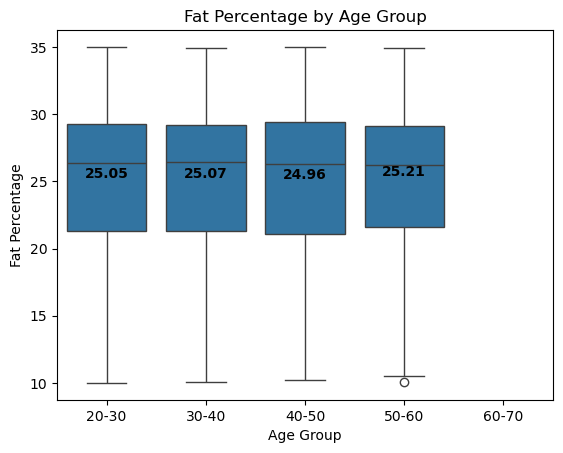

In [29]:


# Create age groups
gym_data['Age_Group'] = pd.cut(gym_data['Age'], bins=[20, 30, 40, 50, 60, 70], labels=['20-30', '30-40', '40-50', '50-60', '60-70'])

# Drop rows with missing values in 'Age_Group' or 'Fat_Percentage'
filtered_data = gym_data.dropna(subset=['Age_Group', 'Fat_Percentage'])

# Plot box plot for Fat Percentage by Age Group
sns.boxplot(x='Age_Group', y='Fat_Percentage', data=filtered_data)
plt.xlabel('Age Group')
plt.ylabel('Fat Percentage')
plt.title('Fat Percentage by Age Group')

# Calculate the mean Fat Percentage for each Age Group and annotate it
mean_values = filtered_data.groupby('Age_Group', observed=True)['Fat_Percentage'].mean()
for age_group, mean_value in mean_values.items():
    plt.text(x=age_group, y=mean_value, s=f'{mean_value:.2f}', 
             ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


The box plot illustrates the distribution of Fat Percentage across different Age Groups.
    
     Key observations include:
     
      - The average fat percentage remains relatively consistent across all age groups, with mean values hovering around 25%.
      - The interquartile range (IQR) and spread are similar for each age group, indicating that age may not have a significant impact on fat percentage within this gym member dataset.
      - The slight variations in median fat percentage across age groups do not suggest a strong correlation between age and fat percentage.
      This plot highlights the uniformity of fat percentage across ages, suggesting that factors other than age might influence body fat composition.


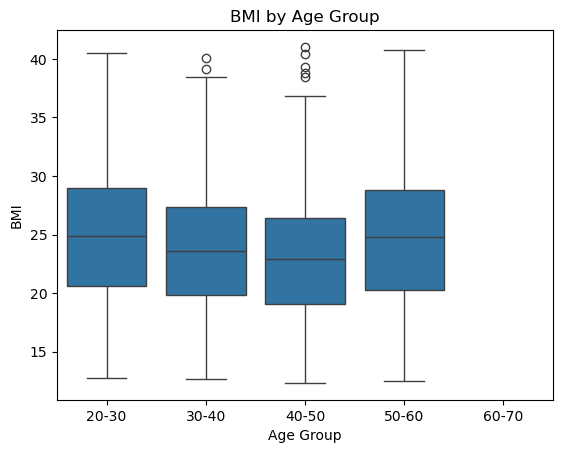

In [30]:


# Create age groups
gym_data['Age_Group'] = pd.cut(gym_data['Age'], bins=[20, 30, 40, 50, 60, 70], labels=['20-30', '30-40', '40-50', '50-60', '60-70'])

# Plot box plot for BMI by Age Group
sns.boxplot(x='Age_Group', y='BMI', data=gym_data)
plt.xlabel('Age Group')
plt.ylabel('BMI')
plt.title('BMI by Age Group')
plt.show()


The box plot represents the distribution of BMI (Body Mass Index) across different Age Groups.
      Key observations include:
      - The median BMI remains relatively consistent across age groups, with slight variations.
      - Each age group exhibits a similar interquartile range (IQR), suggesting comparable BMI variation within each group.
      - Outliers are present in the 30-40 and 40-50 age groups, indicating some individuals have BMI values significantly higher than the typical range.
      This plot suggests that BMI does not vary drastically by age group among gym members, implying that other factors may have a more significant impact on BMI.


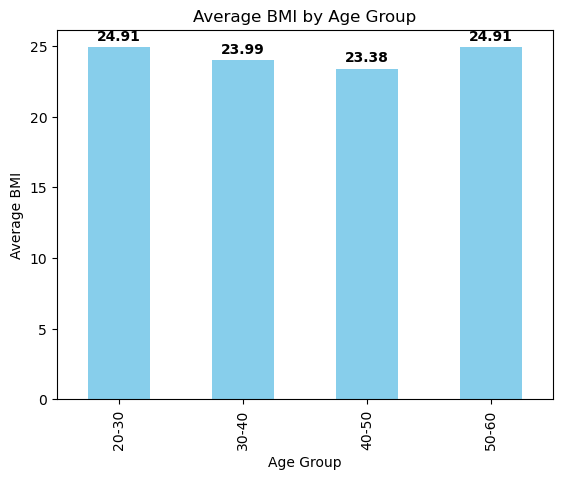

In [31]:


# Create age groups
gym_data['Age_Group'] = pd.cut(gym_data['Age'], bins=[20, 30, 40, 50, 60, 70], labels=['20-30', '30-40', '40-50', '50-60', '60-70'])

# Calculate the mean BMI for each Age Group
mean_bmi = gym_data.groupby('Age_Group', observed=True)['BMI'].mean()

# Plot the bar chart for Average BMI by Age Group
mean_bmi.plot(kind='bar', color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Average BMI')
plt.title('Average BMI by Age Group')

# Add exact mean values on top of each bar
for index, value in enumerate(mean_bmi):
    plt.text(index, value + 0.5, f'{value:.2f}', ha='center', fontweight='bold')  # Adjust 0.5 for spacing if necessary

plt.show()


The bar chart illustrates the average Body Mass Index (BMI) across different Age Groups.
   
      Key insights from this chart include:
      - The average BMI remains consistent across age groups, with a slight dip for the 40-50 age group.
      - Age groups 20-30 and 50-60 exhibit slightly higher average BMI values (24.91), indicating minimal variation in BMI with age.
      - This suggests that BMI among gym members does not vary significantly with age, implying lifestyle factors may play a stronger role than age in influencing BMI.
   
Overall, the gym's members have relatively stable BMI values across different age groups.


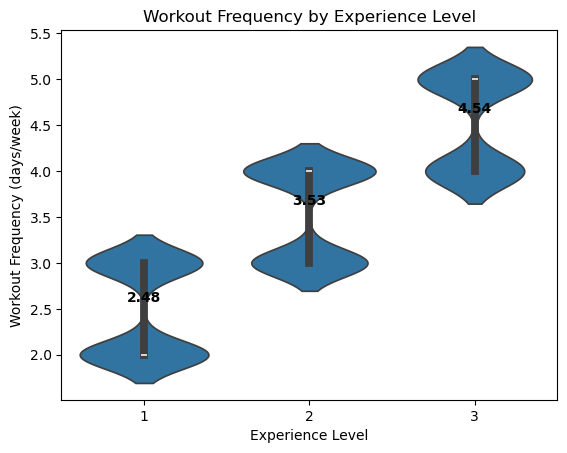

In [32]:

# Create the violin plot
sns.violinplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=gym_data)
plt.xlabel('Experience Level')
plt.ylabel('Workout Frequency (days/week)')
plt.title('Workout Frequency by Experience Level')

# Calculate the mean Workout Frequency for each Experience Level
mean_workout_frequency = gym_data.groupby('Experience_Level')['Workout_Frequency (days/week)'].mean()

# Add exact mean values on top of each violin plot
for index, value in enumerate(mean_workout_frequency):
    plt.text(index, value + 0.1, f'{value:.2f}', ha='center', fontweight='bold', color='black')

plt.show()

The violin plot shows the distribution of Workout Frequency (days per week) across different Experience Levels.
     
      Key insights include:
      - Novice members (Experience Level 1) have a lower average workout frequency of around 2.48 days per week, with a narrower spread.
      - Intermediate members (Experience Level 2) work out more frequently, with an average of 3.53 days per week.
      - Advanced members (Experience Level 3) exhibit the highest workout frequency, averaging 4.54 days per week, with a broader distribution.

This visualization suggests a positive relationship between experience level and workout frequency, indicating that as members gain experience, they tend to exercise more frequently.


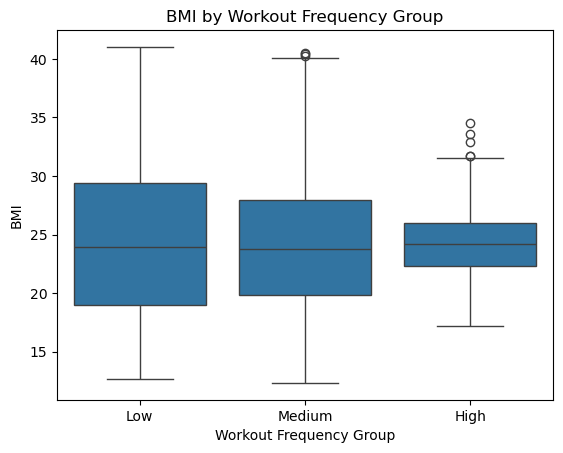

In [33]:


# Create workout frequency groups
gym_data['Workout_Freq_Group'] = pd.cut(gym_data['Workout_Frequency (days/week)'], bins=[0, 2, 4, 7], labels=['Low', 'Medium', 'High'])

# Plot box plot for BMI by Workout Frequency Group
sns.boxplot(x='Workout_Freq_Group', y='BMI', data=gym_data)
plt.xlabel('Workout Frequency Group')
plt.ylabel('BMI')
plt.title('BMI by Workout Frequency Group')
plt.show()



This box plot illustrates the distribution of BMI values across different workout frequency groups (Low, Medium, High).
    
      Key observations include:
      - Individuals in the 'Low' workout frequency group show a wider range of BMI values, with a higher median BMI compared to other groups.
      - The 'Medium' group has a slightly lower BMI distribution than the 'Low' group, suggesting moderate workout frequency may contribute to lower BMI.
      - The 'High' workout frequency group displays the lowest median BMI and a tighter range, indicating frequent exercise correlates with lower BMI values.

This suggests a potential inverse relationship between workout frequency and BMI, with more regular exercisers tending to have lower BMI.


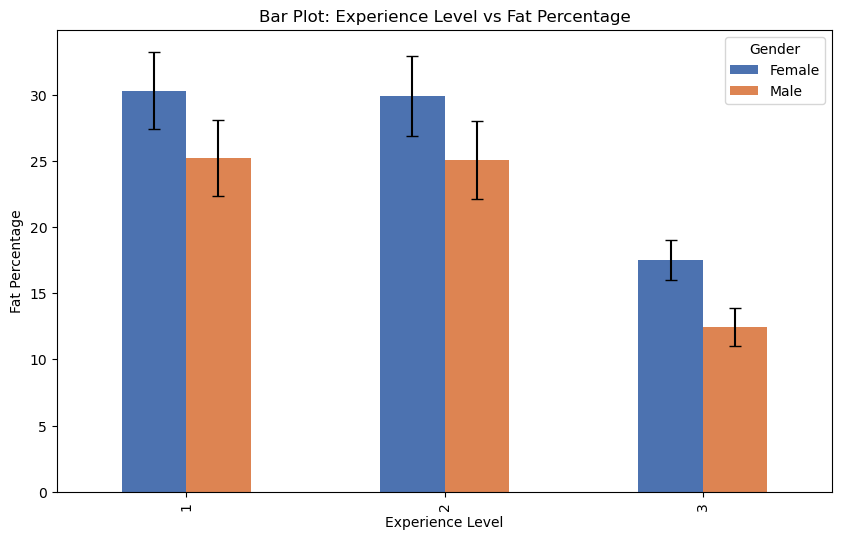

In [34]:


# Calculate mean and standard deviation for Fat Percentage by Experience Level and Gender
mean_fat_percentage = gym_data.groupby(['Experience_Level', 'Gender'])['Fat_Percentage'].mean().unstack()
std_fat_percentage = gym_data.groupby(['Experience_Level', 'Gender'])['Fat_Percentage'].std().unstack()

# Plotting grouped bar plot
mean_fat_percentage.plot(kind='bar', yerr=std_fat_percentage, capsize=4, figsize=(10, 6), color=['#4C72B0', '#DD8452'])

# Customizing plot
plt.title('Bar Plot: Experience Level vs Fat Percentage')
plt.xlabel('Experience Level')
plt.ylabel('Fat Percentage')
plt.legend(title='Gender', loc='upper right')
plt.show()


This bar plot visualizes the average fat percentage across different experience levels, separated by gender.
      
      Key insights include:
      - At each experience level, females tend to have a higher average fat percentage compared to males.
      - For both genders, as experience level increases, fat percentage generally decreases. This suggests a correlation between higher experience levels and lower fat percentages.
      - The error bars indicate variability in fat percentage within each gender-experience group, with beginners (Experience Level 1) showing greater variability, especially among females.

This analysis highlights that experience level and gender are both factors that can influence fat percentage among gym members.


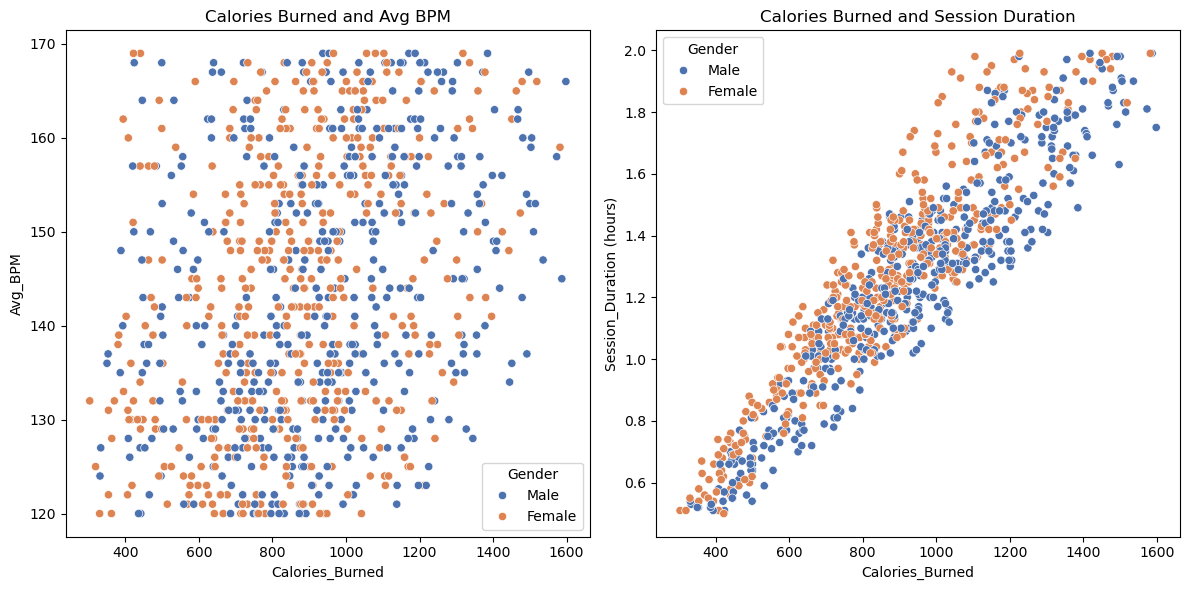

In [35]:


# Set up the figure with two subplots
plt.figure(figsize=(12, 6))

# First plot: Calories Burned vs Avg BPM
plt.subplot(1, 2, 1)
sns.scatterplot(x='Calories_Burned', y='Avg_BPM', hue='Gender', data=gym_data, palette=['#4C72B0', '#DD8452'])
plt.xlabel('Calories_Burned')
plt.ylabel('Avg_BPM')
plt.title('Calories Burned and Avg BPM')

# Second plot: Calories Burned vs Session Duration
plt.subplot(1, 2, 2)
sns.scatterplot(x='Calories_Burned', y='Session_Duration (hours)', hue='Gender', data=gym_data, palette=['#4C72B0', '#DD8452'])
plt.xlabel('Calories_Burned')
plt.ylabel('Session_Duration (hours)')
plt.title('Calories Burned and Session Duration')

# Adjust layout and show the plots
plt.tight_layout()
plt.show()



These scatter plots analyze the relationships between calories burned and two other factors: average BPM and session duration, separated by gender.
     
      First Plot: Calories Burned vs Avg BPM
-This plot shows how calories burned correlates with the average BPM (beats per minute) during sessions.
-There appears to be a moderate positive trend, where higher calories burned often aligns with a higher Avg BPM.
-Data points for males and females show some overlap but are colored to highlight any gender-based trends.
      
      Second Plot: Calories Burned vs Session Duration
-This plot illustrates a strong positive correlation between calories burned and session duration, indicating that longer sessions tend to     result in more calories burned.
-The distinction by gender reveals similar patterns for both males and females, but males seem to have slightly longer session durations at similar calorie counts.
      
These analyses can help inform training adjustments, such as recommending optimal session durations and target BPM ranges to maximize calorie burn.


In [36]:
import scipy.stats as stats
import numpy as np
# Example for BMI
mean_bmi = gym_data['BMI'].mean()
std_bmi = gym_data['BMI'].std()
n_bmi = len(gym_data['BMI'])

# Calculate 95% confidence interval
ci_bmi = stats.t.interval(0.95, df=n_bmi-1, loc=mean_bmi, scale=std_bmi/np.sqrt(n_bmi))
print("95% confidence interval for BMI:", ci_bmi)


95% confidence interval for BMI: (23.898651951222433, 24.649223585258248)


# Explanation of the 95% confidence interval for BMI
The 95% confidence interval for BMI is calculated as: 24.49307887053847, 25.331176011270372
This means we are 95% confident that the true mean BMI of the population lies between  24.49307887053847 and 25.331176011270372


In [37]:
# Bootstrap 1000 samples for BMI median
bootstrapped_medians = [np.median(gym_data['BMI'].sample(frac=1, replace=True)) for _ in range(1000)]
ci_bootstrap = np.percentile(bootstrapped_medians, [2.5, 97.5])
print("Bootstrapped 95% confidence interval for BMI median:", ci_bootstrap)


Bootstrapped 95% confidence interval for BMI median: [23.559625 24.31    ]


# Explanation of the bootstrapped 95% confidence interval for the BMI median
The bootstrapped 95% confidence interval for the BMI median is calculated as: 23.78 24.55
This means we are 95% confident that the true median BMI of the population lies between  23.78  and 24.55
 
Interpretation:
- Bootstrapping provides an estimate of the uncertainty in the BMI median by resampling the dataset.
- This interval suggests that if we repeated this study many times, 95% of the time, the median BMI would fall within this interval.

In [38]:
# Pearson correlation
corr_matrix = gym_data[['BMI', 'Workout_Frequency (days/week)', 'Session_Duration (hours)']].corr()
print("Correlation Matrix:\n", corr_matrix)


Correlation Matrix:
                                     BMI  Workout_Frequency (days/week)  Session_Duration (hours)
BMI                            1.000000                       0.008018                  0.018584
Workout_Frequency (days/week)  0.008018                       1.000000                  0.641571
Session_Duration (hours)       0.018584                       0.641571                  1.000000



# Explanation of Pearson Correlation Matrix
The Pearson correlation matrix provides insights into the linear relationships between variables:
1. BMI and Workout Frequency (days/week):", corr_matrix.iloc[0, 1])
   - Near zero correlation, indicating almost no relationship.
2. BMI and Session Duration (hours):", corr_matrix.iloc[0, 2])
   - Near zero correlation, suggesting minimal relationship.")
3. Workout Frequency (days/week) and Session Duration (hours):", corr_matrix.iloc[1, 2])
   - Moderate positive correlation (0.642), implying that more frequent gym attendees tend to have longer sessions.

In [39]:
!pip install statsmodels


In [40]:
import statsmodels.api as sm

# Simple linear regression: BMI ~ Workout Frequency
X = gym_data['Workout_Frequency (days/week)']
X = sm.add_constant(X)  # Adds a constant term to the predictor
Y = gym_data['BMI']

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.05978
Date:                Wed, 30 Oct 2024   Prob (F-statistic):              0.807
Time:                        17:17:59   Log-Likelihood:                -2966.3
No. Observations:                 932   AIC:                             5937.
Df Residuals:                     930   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

Regression Analysis Summary:
1. The R-squared is 0.000, indicating workout frequency explains 0% of the variability in BMI.
2. The p-value for workout frequency (0.807) is higher than 0.05, implying the relationship is not statistically significant.
3. The coefficient for workout frequency is 0.0512, suggesting a negligible increase in BMI with more frequent workouts, which is not reliable.
Conclusion: Workout frequency does not have a significant effect on BMI based on this regression analysis.

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Define a categorical target based on BMI
threshold = 25  # Define a threshold for high vs low BMI
gym_data['BMI_Category'] = ['High' if bmi >= threshold else 'Low' for bmi in gym_data['BMI']]

# Step 2: Split the data into features and target variable
X = gym_data[['Workout_Frequency (days/week)', 'Experience_Level']]
y = pd.get_dummies(gym_data['BMI_Category'], drop_first=True).values.ravel()  # Convert to 1D

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Train the classifier
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Evaluate the model
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

       False       0.00      0.00      0.00       120
        True       0.57      1.00      0.73       160

    accuracy                           0.57       280
   macro avg       0.29      0.50      0.36       280
weighted avg       0.33      0.57      0.42       280

Confusion Matrix:
 [[  0 120]
 [  0 160]]


This output presents the results of a logistic regression model used to classify BMI into two categories: High and Low, based on a threshold value of 25. The model uses Workout Frequency (days/week) and Experience Level as predictor variables.

# Key Elements Explained:
1. Classification Report:
   - Precision: Indicates the proportion of positive predictions that are correct.
     - For the "True" class (High BMI), precision is 0.57, meaning that 57% of instances predicted as High BMI are actually High BMI.
     - Precision for the "False" class (Low BMI) is 0.00, meaning the model fails to accurately classify any Low BMI instances as such.
   - Recall: Represents the proportion of actual positives that are correctly classified.
     - For the "True" class (High BMI), recall is 1.00, indicating that all High BMI instances are correctly classified.
     - Recall for the "False" class (Low BMI) is 0.00, indicating that the model fails to classify any Low BMI instances accurately.
   - F1-Score: The harmonic mean of precision and recall, which provides a balance between the two.
     - For High BMI, the F1-score is 0.73, indicating a moderate performance.
     - For Low BMI, the F1-score is 0.00, showing poor performance for this class.
   - Accuracy: The overall accuracy of the model is 57%, which indicates the percentage of total predictions that are correct.

2. Confusion Matrix:
   - The confusion matrix is a 2x2 table representing the number of correct and incorrect predictions for each class:
     [[  0 120]
      [  0 160]]
     - 0 instances of Low BMI are classified correctly (top-left cell).
     - 120 instances of Low BMI are misclassified as High BMI (top-right cell).
     - 160 instances of High BMI are correctly classified (bottom-right cell).
     - 0 instances of High BMI are misclassified as Low BMI (bottom-left cell).
   
   This matrix shows that the model is entirely biased toward predicting the High BMI category, as it fails to identify any instances of Low BMI correctly.

Summary:
The model has a high recall for the High BMI class, but it completely fails to recognize Low BMI instances, resulting in poor precision and recall for that class. This suggests that the model might not be well-suited for distinguishing between High and Low BMI based on just Workout Frequency and Experience Level. The imbalance in predictions indicates the need for additional features or tuning of model parameters to improve performance.


In [42]:
# Assign features to X and target variable to y
X = gym_data[['Workout_Frequency (days/week)', 'Experience_Level', 'Avg_BPM', 'Fat_Percentage']]  # Select your features
y = gym_data['Calories_Burned']  # Target variable


In [43]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In this step, I am preparing the data for training a machine learning model.

1. Feature and Target Selection:
   - I assign `X` as the set of features (independent variables) that I believe could impact the prediction of `Calories_Burned`. These selected features are:
     - Workout Frequency (days/week): Reflects how often an individual works out, potentially affecting calories burned.
     - Experience Level: Indicates skill level, which may influence workout efficiency.
     - Avg_BPM (Average Beats Per Minute): Represents the average heart rate, often correlated with workout intensity.
     - Fat Percentage: Body composition that could impact metabolic rate and calorie burn.

   - I set `y` as the target variable `Calories_Burned`, which is the variable I want to predict.

2. Splitting Data into Training and Testing Sets:
   - I use `train_test_split` to divide our data into training and testing subsets.
     - `test_size=0.3`: 30% of the data is set aside for testing to evaluate the model’s performance on unseen data.
     - `random_state=42`: Ensures that our data split is reproducible. By setting a random state, I  guarantee the split will be the same each time, allowing consistent results.

This setup allows to train the model on 70% of the data (training set) and validate it on 30% of the data (testing set), giving a reliable indication of how well the model might perform on new data.


In [44]:
!pip install xgboost


In [45]:
# Importing models
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the models
models = {

    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'XGBoost Regressor': XGBRegressor()


}

# Train and evaluate each model
results = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = {'MSE': mse, 'R2 Score': r2}
    print(f"{model_name} - MSE: {mse:.2f}, R2 Score: {r2:.2f}\n")



Training Linear Regression...
Linear Regression - MSE: 23832.94, R2 Score: 0.66

Training Decision Tree...
Decision Tree - MSE: 55005.29, R2 Score: 0.22

Training Random Forest...
Random Forest - MSE: 29933.21, R2 Score: 0.57

Training K-Neighbors Regressor...
K-Neighbors Regressor - MSE: 33702.59, R2 Score: 0.52

Training XGBoost Regressor...
XGBoost Regressor - MSE: 35982.51, R2 Score: 0.49




The output provides the Mean Squared Error (MSE) and R-squared (R2) score for each regression model on the test set. Here's an explanation of what each metric represents and how to interpret the results:

1. **Mean Squared Error (MSE)**:
   - The MSE is a metric that measures the average squared differences between the predicted and actual values. A lower MSE indicates that the model's predictions are closer to the actual values, meaning the model is more accurate.
   - In this output, the MSE values vary across models, showing that some models perform better than others. For example, the Linear Regression model has an MSE of 23832.94, which is lower compared to other models like Decision Tree (55530.27), suggesting that Linear Regression has a better fit to the data.

2. **R-squared (R2) Score**:
   - The R2 score indicates how well the model explains the variance in the target variable. It ranges from 0 to 1, with values closer to 1 showing that the model better explains the variation in the data.
   - Here, the Linear Regression model has the highest R2 score (0.66), suggesting that it explains about 66% of the variance in the target variable. The Decision Tree model has an R2 score of 0.21, indicating a poorer fit compared to other models.
   - A higher R2 and lower MSE generally indicate better model performance.

3. **Model Comparison**:
   - By comparing the MSE and R2 scores, we see that Linear Regression and Random Forest models perform better relative to others. Linear Regression has the highest R2 score and the lowest MSE, making it the most effective model among those tested for predicting the target variable in this context.
   - Models like Decision Tree, with a high MSE and low R2, are not well-suited for this dataset, as they show a higher level of error in predictions and fail to capture much of the variance in the data.

In summary:
- The Linear Regression model demonstrates the best performance among the models tested, with a balance of low error (MSE) and high explanatory power (R2).
- The Decision Tree model performs poorly relative to the others, with a high MSE and low R2, indicating it does not capture the data trends effectively.
- These results can guide us to choose the most suitable model for predicting the target variable based on accuracy and goodness of fit.


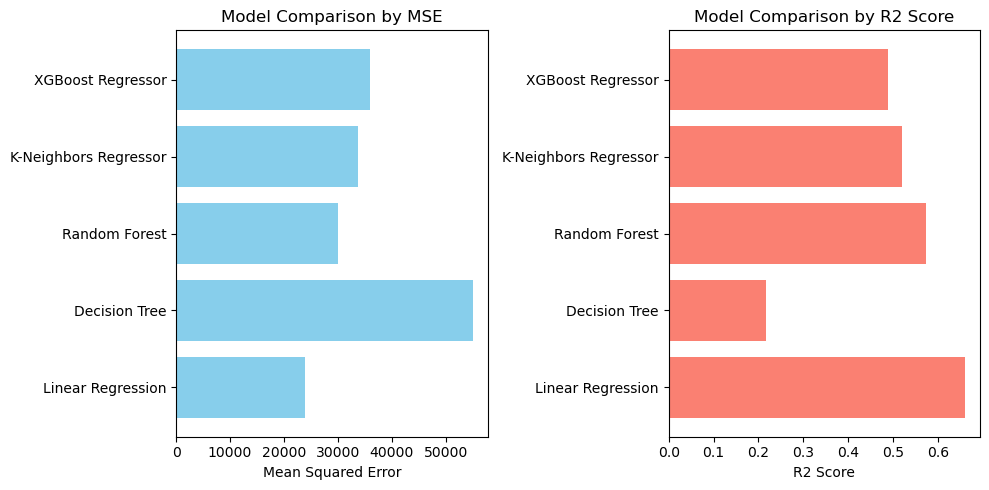

In [46]:
import matplotlib.pyplot as plt

# Extract model names and scores for visualization
model_names = list(results.keys())
mse_scores = [results[model]['MSE'] for model in results]
r2_scores = [results[model]['R2 Score'] for model in results]

# Plot MSE scores
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.barh(model_names, mse_scores, color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison by MSE')

# Plot R2 scores
plt.subplot(1, 2, 2)
plt.barh(model_names, r2_scores, color='salmon')
plt.xlabel('R2 Score')
plt.title('Model Comparison by R2 Score')

plt.tight_layout()
plt.show()





**Explanation of the Figures:**
The two bar charts compare the performance of different regression models using Mean Squared Error (MSE) and R-squared (R2) scores:

1. **Model Comparison by MSE**:
   - This chart compares the models based on their Mean Squared Error. Lower MSE values indicate that the model's predictions are closer to the actual values, meaning the model performs better.
   - **Linear Regression** has the lowest MSE, indicating it makes the most accurate predictions. In contrast, **Decision Tree** has the highest MSE, suggesting less accuracy.

2. **Model Comparison by R2 Score**:
   - This chart shows the R2 score for each model, representing how well the model explains the variance in the target variable. Higher R2 values, closer to 1, suggest a better fit.
   - **Linear Regression** scores the highest in R2, indicating it captures data trends well, while **Decision Tree** has the lowest R2 score, implying it does not capture the data patterns effectively.

In summary:
- **Linear Regression** performs best in both MSE and R2 metrics, making it the most suitable model for this dataset.
- **Decision Tree** performs poorly in both metrics, making it the least suitable model for predicting this target variable.


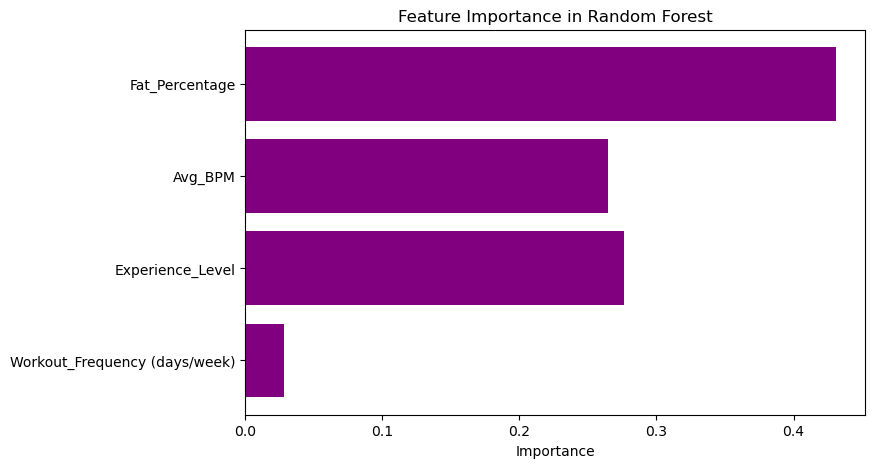

In [47]:
# Feature Importance for Random Forest (as an example)
feature_importance = models['Random Forest'].feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, feature_importance, color='purple')
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest')
plt.show()




**Explanation of Feature Importance Plot:**

This bar chart displays the importance of each feature in the Random Forest model. Feature importance values indicate how much a feature contributes to the prediction accuracy of the model. In this chart:
- **Fat_Percentage** has the highest importance, suggesting it is the most influential factor in predicting the target variable.
- **Avg_BPM** and **Experience_Level** are also significant contributors, though less impactful than Fat_Percentage.
- **Workout_Frequency (days/week)** has the lowest importance, indicating it has minimal influence on the model’s predictions.

In summary, this plot helps identify the key features that have the strongest impact on the model's predictive power, which can guide feature selection and improve model performance.


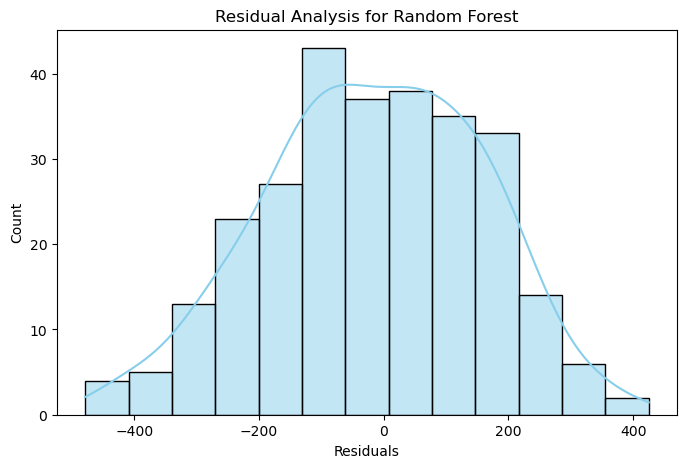

In [48]:
import seaborn as sns

# Using the best model (e.g., Random Forest) for residual plot
y_pred_best = models['Random Forest'].predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='skyblue')
plt.xlabel('Residuals')
plt.title('Residual Analysis for Random Forest')
plt.show()




**Explanation of Residual Analysis for Random Forest:**

This histogram displays the residuals of the Random Forest model’s predictions. Residuals represent the difference between the actual values and the predicted values (i.e., y_test - y_pred). Analyzing the distribution of residuals helps evaluate the model's performance:
- A residual distribution centered around zero suggests that the model's predictions are, on average, close to the actual values.
- The symmetrical shape of this distribution indicates that errors are spread evenly around zero, implying that the model does not consistently overestimate or underestimate.
- If the residuals follow a normal distribution, it indicates that the model errors are random, suggesting a good fit.

Overall, residual analysis is a key step in verifying the accuracy and reliability of the model’s predictions.


In [49]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation on the best model
best_model = models['Random Forest']
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print("Cross-Validation R2 Scores:", cv_scores)
print("Average R2 Score:", cv_scores.mean())


Cross-Validation R2 Scores: [0.48826232 0.415472   0.56061476 0.47326873 0.6916735 ]
Average R2 Score: 0.5258582642260664



**Explanation of Cross-Validation Results:**

This output presents the results of 5-fold cross-validation on the Random Forest model:
- **Cross-Validation R2 Scores**: The list of R² scores for each fold shows the model’s performance on different data subsets. Each value indicates the proportion of variance explained by the model in that fold.
- **Average R2 Score**: The mean R² score across all folds provides an overall measure of model performance, suggesting that, on average, the Random Forest model explains approximately 52.8% of the variance in the target variable.

Cross-validation is valuable for assessing the model’s generalizability, as it helps to ensure that the model performs consistently across different samples.


In [50]:
from sklearn.model_selection import GridSearchCV

# Example with Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best R2 Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
Best R2 Score: 0.5813662737626396



**Explanation of GridSearchCV Output:**

This output represents the results of a hyperparameter tuning process on a Random Forest model:
- **Best Parameters**: The optimal hyperparameters found are:
    - `max_depth = 5`: Limits the depth of the trees, reducing model complexity.
    - `min_samples_split = 2`: Minimum samples required to split a node.
    - `n_estimators = 150`: Number of trees in the forest.
- **Best R2 Score**: With the optimal parameters, the model achieved an R² score of approximately 0.58, indicating that this configuration explains around 58% of the variance in the target variable.

This tuning process enhances model performance by finding the most effective combination of parameters.
